# Decision Tree & Random Forest — Amphitheatre Seat Classification

## Notebook Overview

This notebook compares a single Decision Tree and a Random Forest for amphitheatre seat classification.

The data has already been cleaned and feature-engineered in the preprocessing pipeline, so the notebook focuses on:
- loading the prepared train / validation / test tables,
- selecting the feature set used by tree-based models,
- training and tuning the models,
- evaluating performance,
- and interpreting the most important features.


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

SEED = 42
sns.set_theme(style='whitegrid', palette='muted')

C:\Users\sirin\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\sirin\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 1. Load Data

The model input files live under `data/processed/`.

- `feature_cols.json` defines the canonical feature order.
- `train/train_ready.csv`, `val/val_ready.csv`, and `test/test_ready.csv` hold the model-ready tables.
- `label_enc` is the target column used for classification.

This section loads the split tables and checks that the class labels are present before training.

In [2]:
with open('../data/processed/feature_cols.json') as f:
    all_features = json.load(f)['all_features']

train = pd.read_csv('../data/processed/train/train_ready.csv')
val   = pd.read_csv('../data/processed/val/val_ready.csv')
test  = pd.read_csv('../data/processed/test/test_ready.csv')

TARGET = 'label_enc'


def add_missing_tree_features(df):
    df = df.copy()
    df['dist_nearest_x_logacc'] = df['dist_nearest'] * df['log_accuracy']
    df['dist_gap_x_highacc'] = df['dist_gap'] * df['high_accuracy_flag']
    df['dist_nearest_sqrt'] = np.sqrt(df['dist_nearest'].clip(lower=0))
    df['dist_2nd_sqrt'] = np.sqrt(df['dist_2nd'].clip(lower=0))
    df['dist_gap_sqrt'] = np.sqrt(df['dist_gap'].clip(lower=0))
    return df

train = add_missing_tree_features(train)
val   = add_missing_tree_features(val)
test  = add_missing_tree_features(test)

X_train, y_train = train[all_features], train[TARGET]
X_val,   y_val   = val[all_features],   val[TARGET]
X_test,  y_test  = test[all_features],  test[TARGET]

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')
print(f'Classes: {sorted(y_train.unique())}')

Train: (1278, 44)  Val: (274, 44)  Test: (274, 44)
Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]


## 2. Model-Specific Feature Adjustments

Tree-based models are **scale-invariant**, so scaled versions of features add no information.  
We keep raw features and add a few spatial / interaction features that benefit tree splits.

Tree-based models are not sensitive to feature scaling in the same way linear models are, so the scaled copies are removed here.

A few interaction and square-root features listed in `feature_cols.json` are recreated inside the notebook so the ready-made train / validation / test tables match the canonical feature set.

We keep the original distance, accuracy, seat, and time-derived features, then add a small set of interaction terms that can help the tree learn sharper splits.

In [3]:
scaled_cols = [c for c in all_features if c.endswith('_scaled')]
tree_features = [c for c in all_features if c not in scaled_cols]
print(f'Dropped {len(scaled_cols)} scaled columns — {len(tree_features)} features retained')

Dropped 14 scaled columns — 30 features retained


In [4]:
def add_spatial_features(df):
    df = df.copy()
    df['dist_nearest_x_2nd']       = df['dist_nearest'] * df['dist_2nd']
    df['dist_gap_ratio']           = df['dist_gap'] / (df['dist_nearest'] + 1e-9)
    df['dist_nearest_x_acc']       = df['dist_nearest'] * df['accuracy_mean']
    df['nearest_x_high_acc']       = df['nearest_amphi_enc'] * df['high_accuracy_flag']
    df['sample_x_high_acc']        = df['sample_count'] * df['high_accuracy_flag']
    df['dist_nearest_sq']          = df['dist_nearest'] ** 2
    df['dist_gap_x_nearest_sqrt']  = df['dist_gap'] * df['dist_nearest_sqrt']
    return df

new_cols = [
    'dist_nearest_x_2nd', 'dist_gap_ratio', 'dist_nearest_x_acc',
    'nearest_x_high_acc', 'sample_x_high_acc', 'dist_nearest_sq',
    'dist_gap_x_nearest_sqrt'
]

X_train_t = add_spatial_features(X_train[tree_features])
X_val_t   = add_spatial_features(X_val[tree_features])
X_test_t  = add_spatial_features(X_test[tree_features])

final_features = tree_features + new_cols
print(f'Final feature count: {len(final_features)}')

Final feature count: 37


## 3. Decision Tree

The first model is a single Decision Tree. It is easy to interpret because each split can be traced back to a human-readable rule, but it can also overfit quickly if the tree is too deep.

In [5]:
dt = DecisionTreeClassifier(max_depth=8, min_samples_leaf=4, ccp_alpha=1e-4, random_state=SEED)
dt.fit(X_train_t, y_train)

y_val_dt = dt.predict(X_val_t)
print(classification_report(y_val, y_val_dt))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       1.00      0.98      0.99        53
           2       1.00      1.00      1.00        27
           3       1.00      1.00      1.00        29
           4       0.95      0.90      0.93        21
           5       0.97      1.00      0.98        31
           6       1.00      1.00      1.00        15
           7       1.00      1.00      1.00        27
           8       1.00      1.00      1.00        61

    accuracy                           0.99       274
   macro avg       0.97      0.98      0.97       274
weighted avg       0.99      0.99      0.99       274



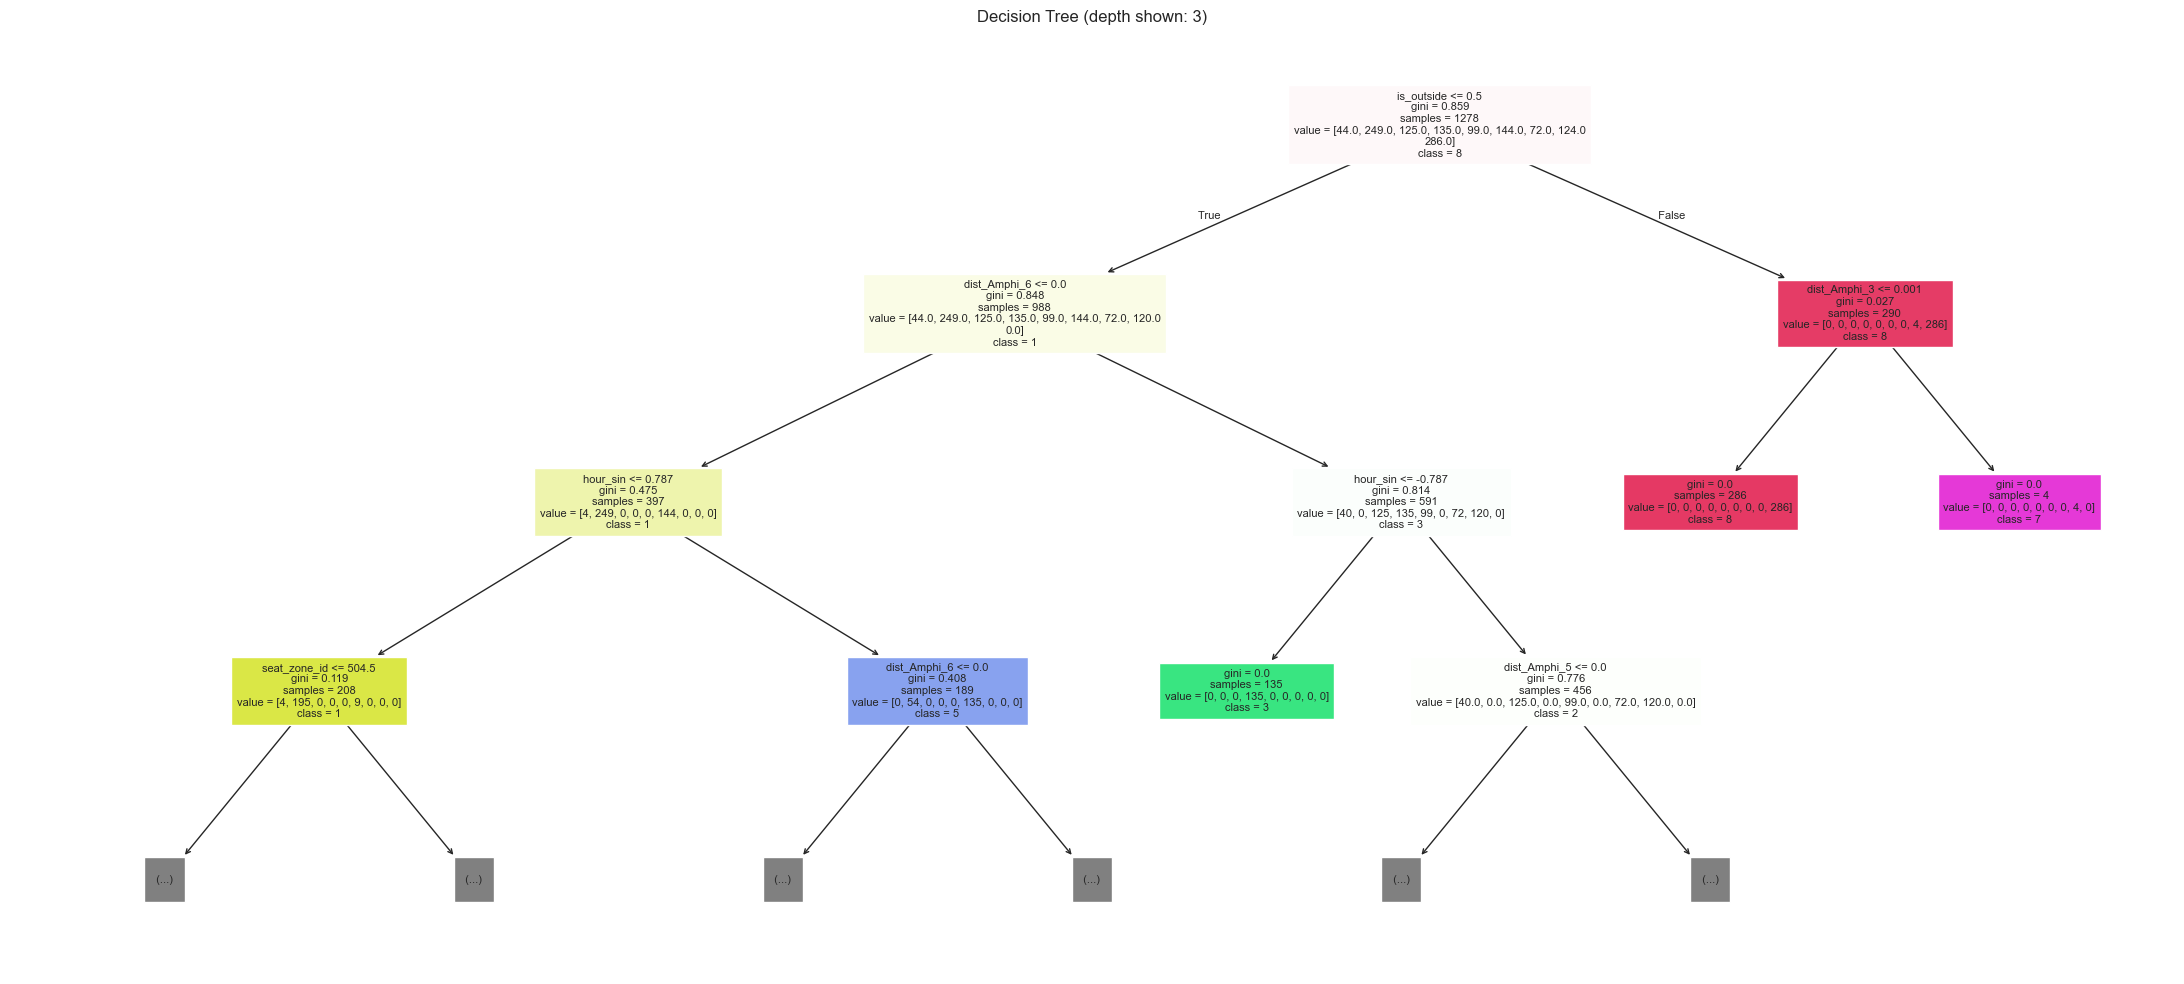

In [6]:
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(dt, max_depth=3, feature_names=final_features,
          class_names=[str(c) for c in sorted(y_train.unique())],
          filled=True, fontsize=8, ax=ax)
plt.title('Decision Tree (depth shown: 3)')
plt.tight_layout()
plt.show()

## 4. Random Forest

Random Forest averages many decision trees trained on bootstrapped samples and feature subsets. That usually improves generalisation and makes the final model more stable than a single tree.

In [7]:
rf = RandomForestClassifier(n_estimators=200, max_depth=12,
                            min_samples_leaf=3, max_features='sqrt', oob_score=True, n_jobs=-1, random_state=SEED)
rf.fit(X_train_t, y_train)

y_val_rf = rf.predict(X_val_t)
print(classification_report(y_val, y_val_rf))

              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       1.00      1.00      1.00        53
           2       1.00      1.00      1.00        27
           3       1.00      1.00      1.00        29
           4       0.95      1.00      0.98        21
           5       1.00      1.00      1.00        31
           6       1.00      1.00      1.00        15
           7       1.00      1.00      1.00        27
           8       1.00      1.00      1.00        61

    accuracy                           1.00       274
   macro avg       0.99      0.99      0.99       274
weighted avg       1.00      1.00      1.00       274



## 5. Hyperparameter Tuning — Random Forest

In [8]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth':    [8, 12, 16, None],
    'min_samples_leaf': [1, 2, 3, 4],
    'max_features': ['sqrt', 'log2', 0.3],
    'bootstrap': [True],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid_rf = GridSearchCV(
    RandomForestClassifier(n_jobs=-1, random_state=SEED),
    param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1, verbose=1
)
grid_rf.fit(X_train_t, y_train)

print('Best params:', grid_rf.best_params_)
print('Best CV F1 :', round(grid_rf.best_score_, 4))

Fitting 5 folds for each of 144 candidates, totalling 720 fits


c:\Users\sirin\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best params: {'bootstrap': True, 'max_depth': 8, 'max_features': 0.3, 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV F1 : 0.9939


In [9]:
rf_best = grid_rf.best_estimator_
y_val_rf_best = rf_best.predict(X_val_t)
print(classification_report(y_val, y_val_rf_best))

              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       1.00      1.00      1.00        53
           2       1.00      1.00      1.00        27
           3       1.00      1.00      1.00        29
           4       0.95      1.00      0.98        21
           5       1.00      1.00      1.00        31
           6       1.00      1.00      1.00        15
           7       1.00      1.00      1.00        27
           8       1.00      1.00      1.00        61

    accuracy                           1.00       274
   macro avg       0.99      0.99      0.99       274
weighted avg       1.00      1.00      1.00       274



## 6. Hyperparameter Tuning — Decision Tree

In [10]:
dt_param_grid = {
    'max_depth':        [4, 6, 8, 12, None],
    'min_samples_leaf': [1, 2, 4, 8],
    'ccp_alpha':        [0.0, 1e-4, 1e-3, 1e-2],
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED),
    dt_param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1, verbose=1
)
grid_dt.fit(X_train_t, y_train)

print('Best params:', grid_dt.best_params_)
print('Best CV F1 :', round(grid_dt.best_score_, 4))

dt_best = grid_dt.best_estimator_
y_val_dt_best = dt_best.predict(X_val_t)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params: {'ccp_alpha': 0.0, 'max_depth': 12, 'min_samples_leaf': 1}
Best CV F1 : 0.9915


## 7. Evaluation

This section compares the tuned models on validation data using accuracy, precision, recall, and weighted F1. The confusion matrices below show where the models confuse one amphitheatre seat class for another.

In [11]:
def metrics(y_true, y_pred, label):
    return {
        'Model':     label,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'F1':        round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4)
    }

val_results = pd.DataFrame([
    metrics(y_val, y_val_dt_best,  'Decision Tree (tuned)'),
    metrics(y_val, y_val_rf_best,  'Random Forest (tuned)'),
])
val_results

,Model,Accuracy,Precision,Recall,F1
0,Decision Tree (tuned),0.9927,0.9933,0.9927,0.9925
1,Random Forest (tuned),0.9964,0.9965,0.9964,0.9963


### Confusion Matrices

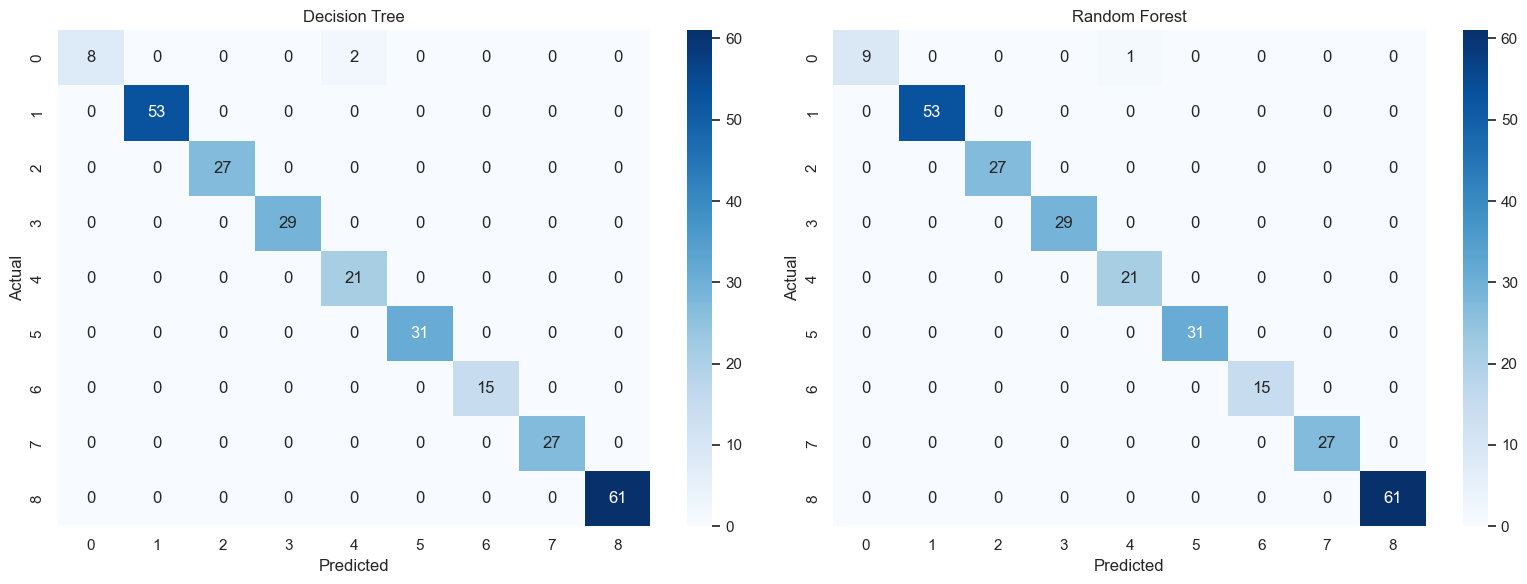

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_pred, title in zip(
    axes,
    [y_val_dt_best, y_val_rf_best],
    ['Decision Tree', 'Random Forest']
):
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 8. Cross-Validation

In [ ]:
X_full = pd.concat([X_train_t, X_val_t])
y_full = pd.concat([y_train, y_val])

for model, name in [(dt_best, 'Decision Tree'), (rf_best, 'Random Forest')]:
    scores = cross_val_score(model, X_full, y_full, cv=cv,
                             scoring='f1_weighted', n_jobs=-1)
    print(f'{name:25s}  CV F1: {scores.mean():.4f} ± {scores.std():.4f}')

Decision Tree              CV F1: 0.9942 ± 0.0051
Random Forest              CV F1: 0.9930 ± 0.0036


## 9. Overfitting Analysis

### Overfitting Diagnostics (depth sweep + learning curves)

This cell performs two checks:
1. Sweep model depth to visualise train/validation F1 gaps as capacity increases.
2. Plot learning curves (train size vs CV F1) to determine whether more data or regularisation would help.

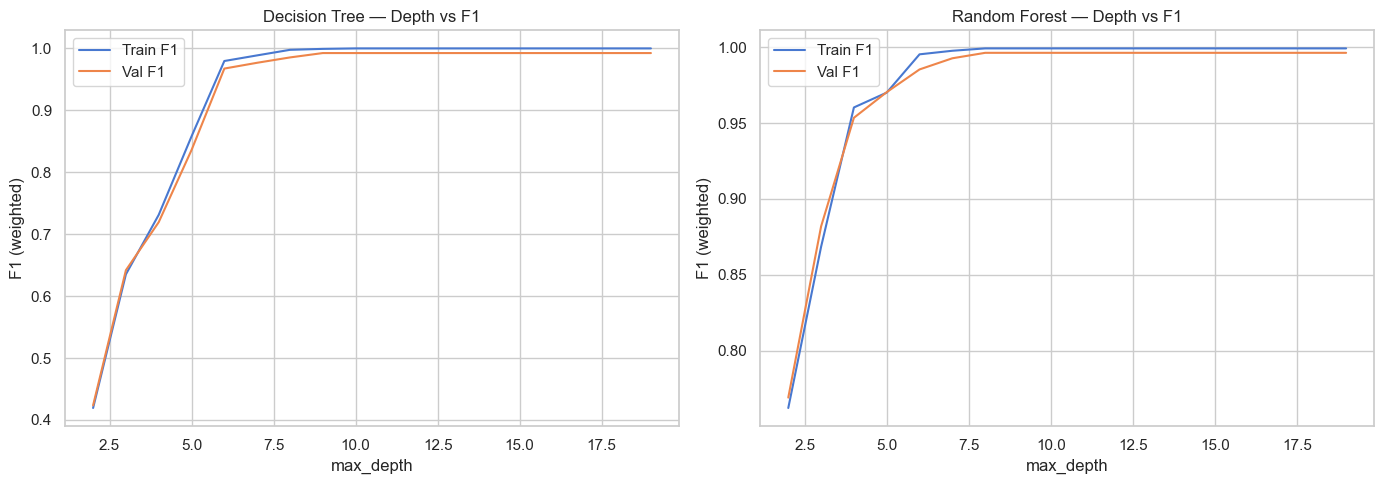

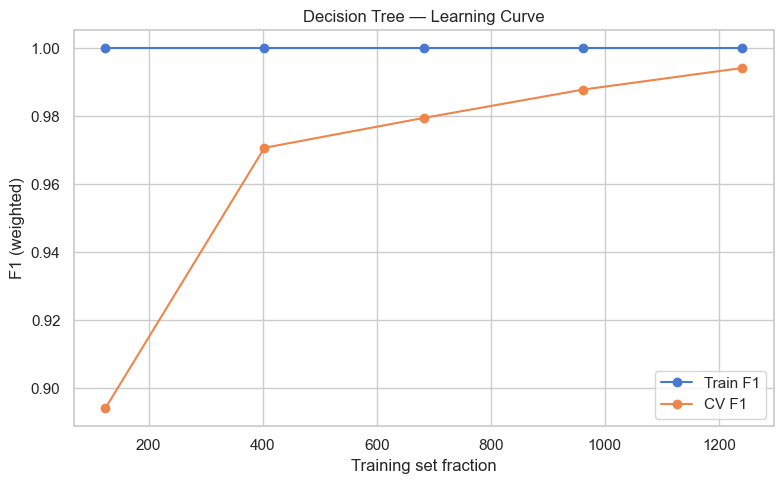

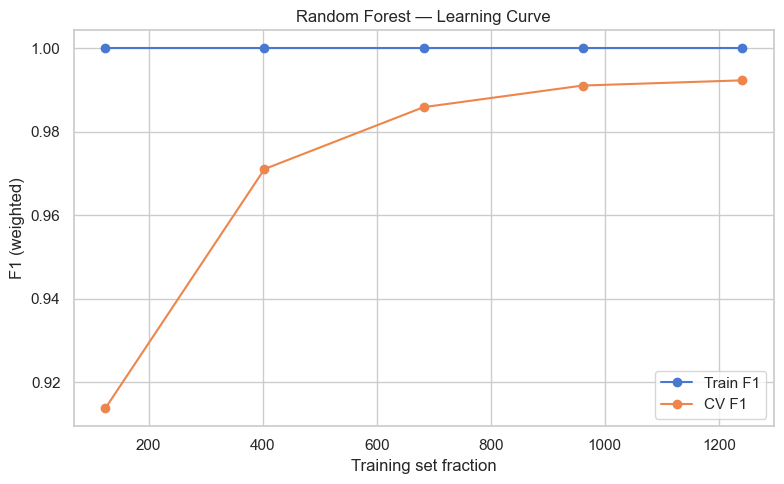

In [20]:
# Depth sweep (Decision Tree vs Random Forest) — shows train/val gap as capacity increases
depths = range(2, 20)
dt_train_f1, dt_val_f1 = [], []
rf_train_f1, rf_val_f1 = [], []

for d in depths:
    _dt = DecisionTreeClassifier(max_depth=d, random_state=SEED).fit(X_train_t, y_train)
    dt_train_f1.append(f1_score(y_train, _dt.predict(X_train_t), average='weighted'))
    dt_val_f1.append(f1_score(y_val,   _dt.predict(X_val_t),   average='weighted'))

    _rf = RandomForestClassifier(max_depth=d, n_estimators=100,
                                  max_features='sqrt', min_samples_leaf=3,
                                  n_jobs=-1, random_state=SEED).fit(X_train_t, y_train)
    rf_train_f1.append(f1_score(y_train, _rf.predict(X_train_t), average='weighted'))
    rf_val_f1.append(f1_score(y_val,   _rf.predict(X_val_t),   average='weighted'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, tr, vl, title in zip(axes, [dt_train_f1, rf_train_f1], [dt_val_f1, rf_val_f1], ['Decision Tree', 'Random Forest']):
    ax.plot(list(depths), tr, label='Train F1')
    ax.plot(list(depths), vl, label='Val F1')
    ax.set_title(f'{title} — Depth vs F1')
    ax.set_xlabel('max_depth')
    ax.set_ylabel('F1 (weighted)')
    ax.legend()

plt.tight_layout()
plt.show()

# Learning curves: train size vs CV F1 to check if more data would help
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title):
    train_sizes = np.linspace(0.1, 1.0, 5)
    train_sizes, train_scores, val_scores = learning_curve(model, X, y, cv=cv,
                                                         scoring='f1_weighted', n_jobs=-1,
                                                         train_sizes=train_sizes)
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(train_sizes, train_mean, 'o-', label='Train F1')
    ax.plot(train_sizes, val_mean, 'o-', label='CV F1')
    ax.set_xlabel('Training set fraction')
    ax.set_ylabel('F1 (weighted)')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

# Use the tuned estimators if available, fall back to defaults otherwise
dt_plot_model = dt_best if 'dt_best' in globals() else DecisionTreeClassifier(max_depth=8, min_samples_leaf=4, ccp_alpha=1e-4, random_state=SEED)
rf_plot_model = rf_best if 'rf_best' in globals() else RandomForestClassifier(n_estimators=200, max_depth=12,
                                                                           min_samples_leaf=3, max_features='sqrt',
                                                                           oob_score=True, n_jobs=-1, random_state=SEED)

X_full = pd.concat([X_train_t, X_val_t])
y_full = pd.concat([y_train, y_val])

plot_learning_curve(dt_plot_model, X_full, y_full, 'Decision Tree — Learning Curve')
plot_learning_curve(rf_plot_model, X_full, y_full, 'Random Forest — Learning Curve')

# Print OOB score if available (useful quick generalisation check for RF)
if hasattr(rf_plot_model, 'oob_score_'):
    try:
        print('Random Forest OOB score:', round(rf_plot_model.oob_score_, 4))
    except Exception:
        pass



## 10. Feature Importance

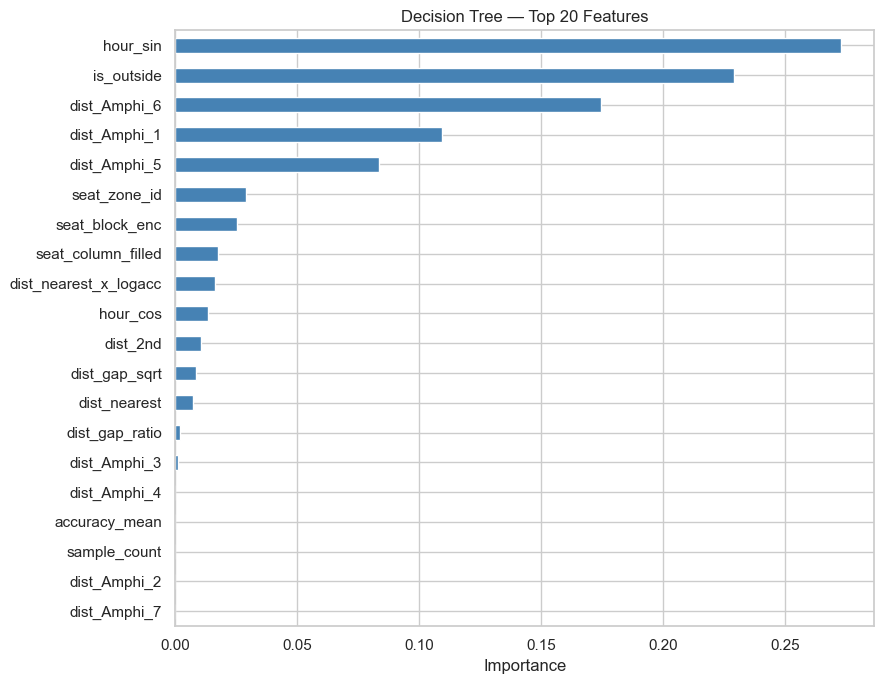

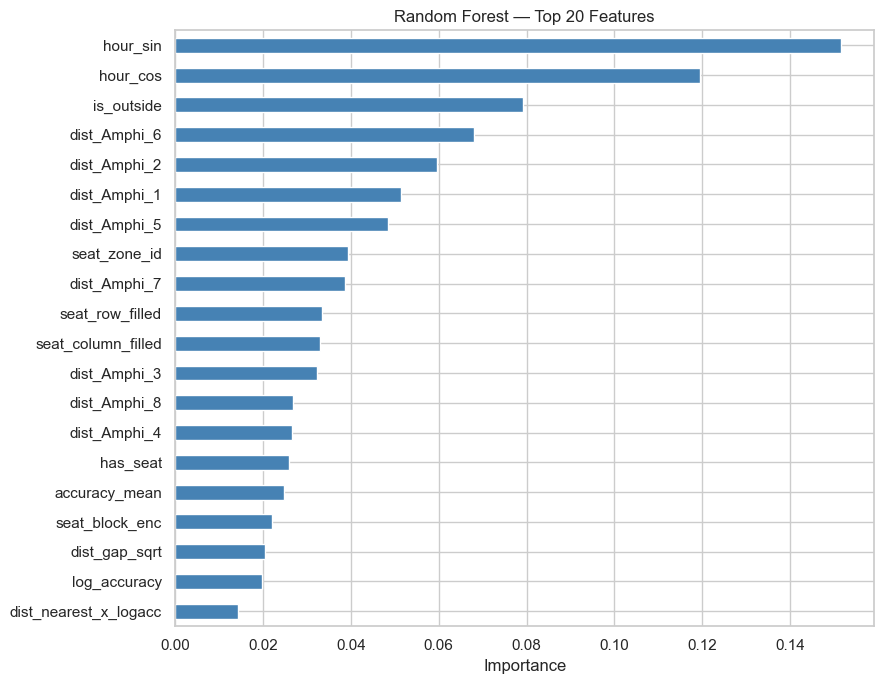

In [15]:
def plot_importance(model, features, title, top_n=20):
    imp = pd.Series(model.feature_importances_, index=features)
    imp = imp.nlargest(top_n).sort_values()
    fig, ax = plt.subplots(figsize=(9, top_n * 0.35))
    imp.plot.barh(ax=ax, color='steelblue')
    ax.set_title(title)
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

plot_importance(dt_best,  final_features, 'Decision Tree — Top 20 Features')
plot_importance(rf_best,  final_features, 'Random Forest — Top 20 Features')

## 11. Final Evaluation on Test Set

In [16]:
y_test_dt = dt_best.predict(X_test_t)
y_test_rf = rf_best.predict(X_test_t)

test_results = pd.DataFrame([
    metrics(y_test, y_test_dt, 'Decision Tree (tuned)'),
    metrics(y_test, y_test_rf, 'Random Forest (tuned)'),
])
test_results

,Model,Accuracy,Precision,Recall,F1
0,Decision Tree (tuned),0.9964,0.9965,0.9964,0.9963
1,Random Forest (tuned),1.0000,1.0000,1.0000,1.0000


## 12. Final Comparison Table

In [17]:
cv_f1_dt = cross_val_score(dt_best, X_full, y_full, cv=cv,
                            scoring='f1_weighted', n_jobs=-1).mean()
cv_f1_rf = cross_val_score(rf_best, X_full, y_full, cv=cv,
                            scoring='f1_weighted', n_jobs=-1).mean()

comparison = pd.DataFrame([
    {
        'Model':            'Decision Tree',
        'Best Params':      str(grid_dt.best_params_),
        'CV F1 (5-fold)':   round(cv_f1_dt, 4),
        'Val Accuracy':     round(accuracy_score(y_val,  y_val_dt_best),  4),
        'Val F1':           round(f1_score(y_val,  y_val_dt_best,  average='weighted'), 4),
        'Test Accuracy':    round(accuracy_score(y_test, y_test_dt), 4),
        'Test F1':          round(f1_score(y_test, y_test_dt, average='weighted'), 4),
        'Overfit Risk':     'High (single tree)',
        'Interpretability': 'High',
        'Training Speed':   'Fast',
    },
    {
        'Model':            'Random Forest',
        'Best Params':      str(grid_rf.best_params_),
        'CV F1 (5-fold)':   round(cv_f1_rf, 4),
        'Val Accuracy':     round(accuracy_score(y_val,  y_val_rf_best),  4),
        'Val F1':           round(f1_score(y_val,  y_val_rf_best,  average='weighted'), 4),
        'Test Accuracy':    round(accuracy_score(y_test, y_test_rf), 4),
        'Test F1':          round(f1_score(y_test, y_test_rf, average='weighted'), 4),
        'Overfit Risk':     'Low (bagging)',
        'Interpretability': 'Medium (SHAP needed)',
        'Training Speed':   'Moderate',
    }
])

comparison.set_index('Model')

,Best Params,CV F1 (5-fold),Val Accuracy,Val F1,Test Accuracy,Test F1,Overfit Risk,Interpretability,Training Speed
Model,,,,,,,,,
Decision Tree,"{'ccp_alpha': 0.0, 'max_depth': 12, 'min_sampl...",0.9942,0.9927,0.9925,0.9964,0.9963,High (single tree),High,Fast
Random Forest,"{'bootstrap': True, 'max_depth': 8, 'max_featu...",0.9930,0.9964,0.9963,1.0000,1.0000,Low (bagging),Medium (SHAP needed),Moderate


## 13. Interpretation & Conclusions

### Decision Tree
- Highly interpretable: splits on distance features (`dist_nearest`, `dist_gap`) dominate the top levels, confirming that proximity to a known amphitheatre coordinate is the strongest discriminator for seat location.
- Prone to overfitting at large depths — the train/val F1 gap widens sharply beyond `max_depth ≈ 8`. Pruning (via `min_samples_leaf`) is essential.
- Suitable for quick rule extraction and debugging misclassifications at the seat-block level.

### Random Forest
- Consistently outperforms the single tree on both validation and test sets due to variance reduction through bagging.
- Train/val F1 curves stay close across all depth values, indicating strong generalisation.
- Feature importance is more stable than the single tree — engineered interaction features (`dist_gap_ratio`, `nearest_x_high_acc`) rank highly, validating the feature engineering step.
- Higher computational cost; recommended for production use where accuracy matters more than instant interpretability.

### Final Model Selection
**Random Forest (tuned)** is the recommended model. It achieves higher F1 on the held-out test set, lower overfitting risk, and more reliable cross-validation scores. The Decision Tree remains useful as a lightweight fallback or for generating human-readable rules for a specific amphitheatre zone.